# **DLS Backtest**

In [398]:
# general 
import os
import sys 
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
# .py 
root = '/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot'
root_path = os.path.abspath(root)
importing_folders = ['data_loaders', 'models']
import_paths = [os.path.join(root, import_path) for import_path in importing_folders]
for p in ([root] + import_paths): 
    if p not in sys.path:
        sys.path.insert(0, p)
from data_loaders.coinbase_data_post_process import coinbase_price_return_data
import models.lstm_trading as lstm 

## **Data** 

In [399]:
# fetch data 
data_universe = {}
data_path = os.path.join(root, 'data')

for f in Path(data_path).iterdir():
    # print path
    print(f)
    # data  
    data = pd.read_csv(f, index_col = 'Unnamed: 0')
    data.set_index(
        pd.DatetimeIndex(data.index), inplace = True
    )
    # append 
    symbol = str(f).split('data/')[-1].split('_')[0]
    data_universe[symbol] = data

/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/data/USDT-GBP_2023-01-01_2026-01-01.csv
/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/data/BTC-GBP_2023-01-01_2026-01-01.csv
/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/data/ETH-GBP_2023-01-01_2026-01-01.csv
/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/data/LINK-GBP_2023-01-01_2026-01-01.csv
/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/data/SOL-GBP_2023-01-01_2026-01-01.csv


In [400]:
# price and return data
data_prices, data_returns = coinbase_price_return_data(data_universe = data_universe)

# join data 
# get lowest common start index
symbol_start = {s: data.index[0] for s, data in data_universe.items()}
max_key = max(symbol_start, key = symbol_start.get) # analgous to np.argmax/argmin

# positional index corresponding to maximum start timestamp
base_data: pd.DataFrame = data_universe[max_key]
drop_index = max(np.isnan(base_data).sum()) 

# join from lowest common index 
for s, data in data_universe.items():
    data_universe[s] = data.iloc[drop_index: , :]

USDT-GBP
dim: (315647, 5)
Column NA counts:
low       0
high      0
open      0
close     0
volume    0
dtype: int64



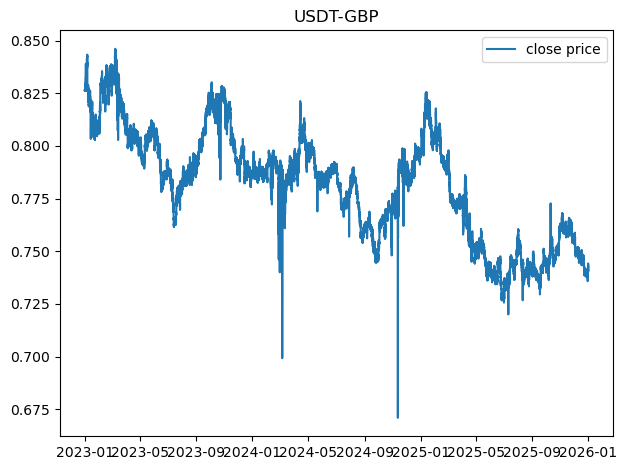


BTC-GBP
dim: (315647, 5)
Column NA counts:
low       0
high      0
open      0
close     0
volume    0
dtype: int64



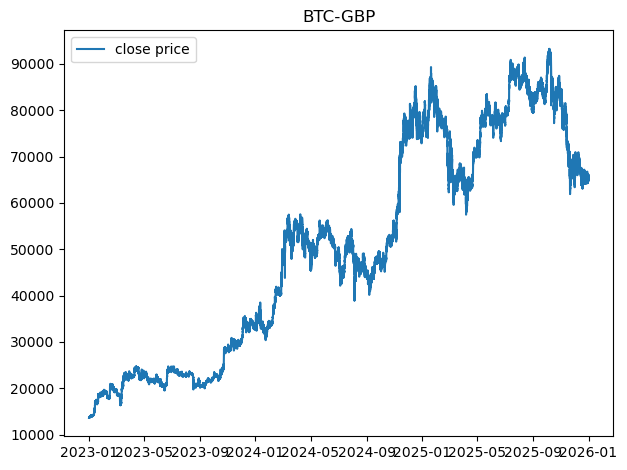


ETH-GBP
dim: (315647, 5)
Column NA counts:
low       0
high      0
open      0
close     0
volume    0
dtype: int64



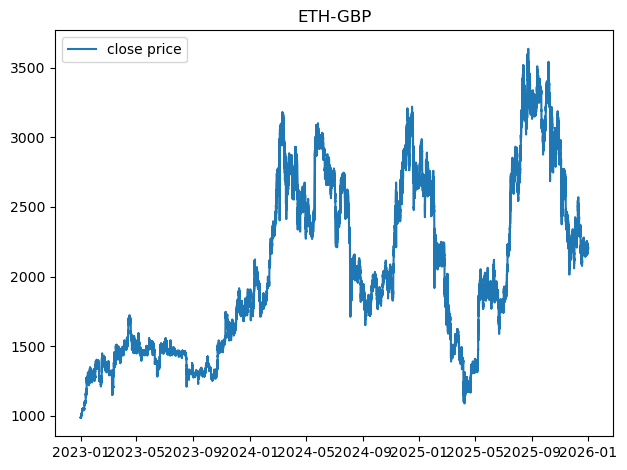


LINK-GBP
dim: (315647, 5)
Column NA counts:
low       0
high      0
open      0
close     0
volume    0
dtype: int64



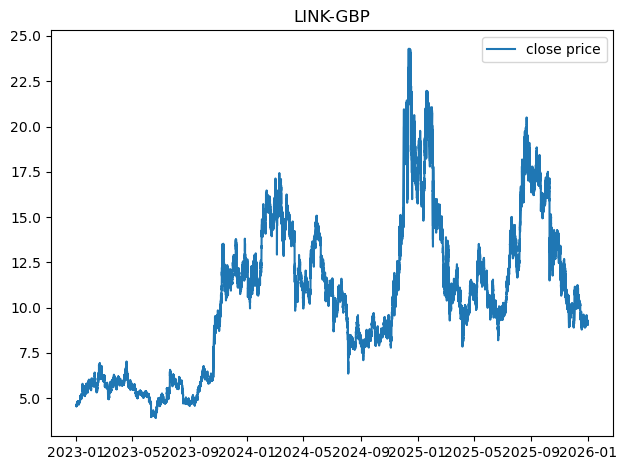


SOL-GBP
dim: (315647, 5)
Column NA counts:
low       0
high      0
open      0
close     0
volume    0
dtype: int64



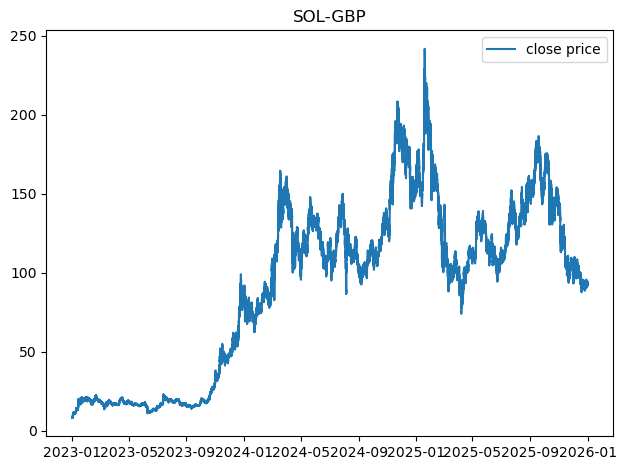

In [401]:
for s, data in data_universe.items():
    # summary 
    print(s)
    print('dim:', data.shape)
    print('Column NA counts:')
    print(np.isnan(data_universe['SOL-GBP']).sum())
    print()

    # plot 
    plt.plot(data['close'], label = 'close price')
    plt.title(s)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print()

## **WFA** 

### **EDA**

total IS/OOS folds: 41
full OOS non zero predictions: 1.0
average IS train set loss: 0.06630256367335889
average IS eval set loss: 0.05659983543853564


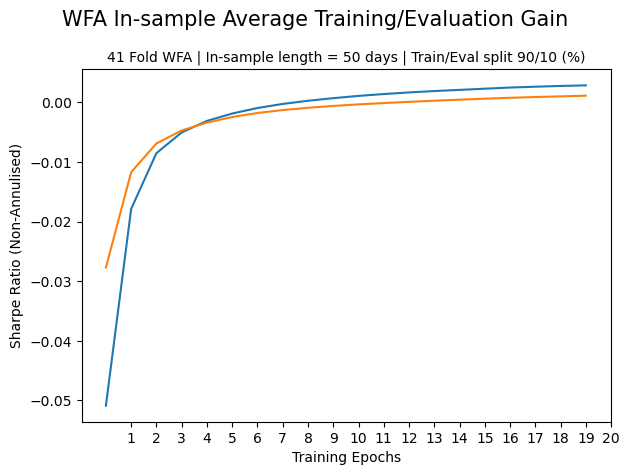

avergae asset weights: [0.20100951 0.19627424 0.20074822 0.23581928 0.12263911]


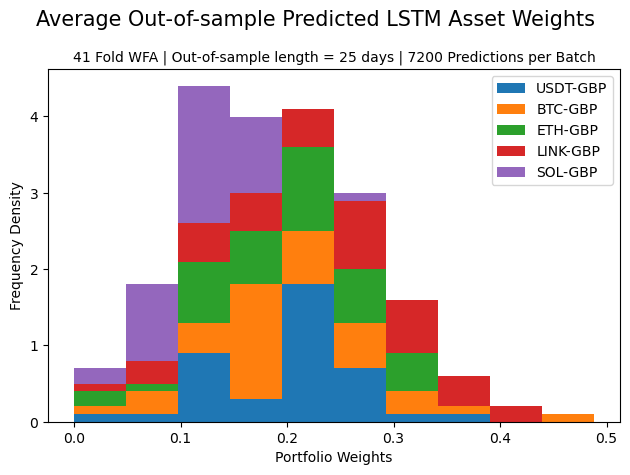

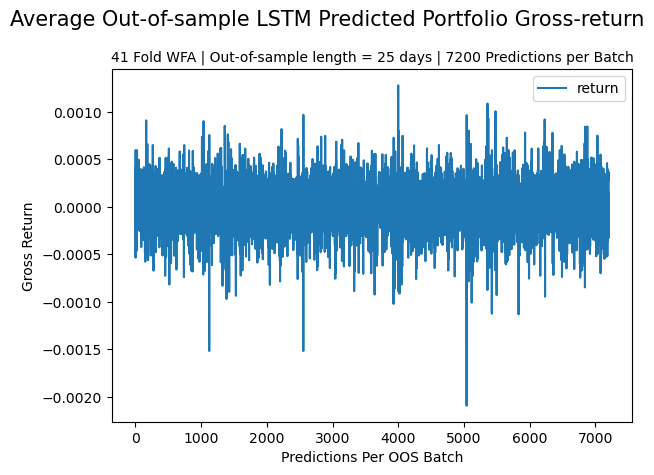

In [402]:
root_path_wfa = '/Users/amjadsaidam/Desktop/Quant stuff /Algorithmic Strategies /coinbase_trading_bot/walk_forward_analysis/wfa.pkl'
with open(root_path_wfa, mode = 'rb') as f: 
    wfa = pickle.load(f)

symbols = wfa.get('symbols', sorted(data_universe.keys()))
bench = 'BTC-GBP'
bench_idx = wfa.get('bench_idx', symbols.index(bench))

# wfa payloads 
wfa_regime = np.array(wfa['regime_mask'])
wfa_w = np.array(wfa['gated_weights'])
wfa_rt = np.array(wfa['gated_returns'])
wfa_vol = wfa['vol_scale']
fold_train_eval_loss = {}
for fold in range(len(wfa_w)):
    fold_train_eval_loss[fold] = {
        'train_losses': wfa['model_train_loss_container'][0], 
        'eval_looses': wfa['model_eval_loss_container'][0]
    }

# metadata 
print('total IS/OOS folds:', len(wfa_w))
# non zero values
rt = np.array(wfa_rt)
rt_non_zero = ~np.isnan(wfa_rt)
rt_non_zero = rt_non_zero.all(axis = 1)
rt_non_zero_idx = np.argwhere(rt_non_zero)
print('full OOS non zero predictions:', len(rt_non_zero_idx) / len(wfa_rt))
print('average IS train set loss:', np.mean([sum(v) for v in wfa['model_train_loss_container']]))
print('average IS eval set loss:', np.mean([sum(v) for v in wfa['model_eval_loss_container']]))

# eval and test losses 
avg_is_train_looses = np.array(wfa['model_train_loss_container']).mean(axis = 0) * -1
avg_is_eval_loosses = np.array(wfa['model_eval_loss_container']).mean(axis = 0) * -1
plt.plot(avg_is_train_looses, label = 'train set')
plt.plot(avg_is_eval_loosses, label = 'eval set')
plt.suptitle('WFA In-sample Average Training/Evaluation Gain', fontsize = 15)
plt.title('41 Fold WFA | In-sample length = 50 days | Train/Eval split 90/10 (%)', fontsize = 10)
plt.xticks(range(1, 21))
plt.xlabel('Training Epochs')
plt.ylabel('Sharpe Ratio (Non-Annulised)')
plt.tight_layout()
plt.show();

# portdolio weights 
full_wfa_w = wfa_w.reshape(-1, wfa_w.shape[-1])
print('avergae asset weights:', full_wfa_w.mean(axis = 0))
oos_avg_w = wfa_w.mean(axis = 1)
plt.hist(oos_avg_w, density = True, stacked = True, label = data_universe.keys())
plt.suptitle('Average Out-of-sample Predicted LSTM Asset Weights', fontsize = 15)
plt.title(f'41 Fold WFA | Out-of-sample length = 25 days | {wfa_w.shape[1]} Predictions per Batch', fontsize = 10)
plt.xlabel('Portfolio Weights')
plt.ylabel('Frequency Density')
plt.legend()
plt.tight_layout()
plt.show();

# portfolio returns 
avg_wfa_pred_rt = wfa_rt.mean(axis = 0)
plt.plot(avg_wfa_pred_rt, label = 'return')
plt.suptitle('Average Out-of-sample LSTM Predicted Portfolio Gross-return', fontsize = 15)
plt.title(f'41 Fold WFA | Out-of-sample length = 25 days | {wfa_w.shape[1]} Predictions per Batch', fontsize = 10)
plt.xlabel('Predictions Per OOS Batch')
plt.ylabel('Gross Return')
plt.legend()
plt.tight_layout()
plt.show();

### **Regimes**

In [403]:
def returns(asset: pd.DataFrame) -> pd.Series: 
    """log returns"""
    asset_close = asset['close']
    return np.log(asset_close / asset_close.shift(periods = 1)).fillna(0.0)

def rolling_corr(benchmark: pd.DataFrame,
                 asset: pd.DataFrame, 
                 window: int = 200):
    """rolling correlation"""
    bench_rt = returns(benchmark)
    asset_rt = returns(asset)

    # rolling corr (Cov_xy / std_x * std_y)
    # rolling cov (Ex * Ey - Exy)
    xy = bench_rt * asset_rt
    e_xy =  xy.rolling(window).mean()
    e_x = bench_rt.rolling(window).mean()
    e_y = asset_rt.rolling(window).mean()
    cov_xy = e_xy - e_x * e_y
    # rolling std 
    std_x = bench_rt.rolling(window).std()
    std_y = asset_rt.rolling(window).std()

    return np.where(
        (std_x * std_y) > 0, cov_xy / (std_x * std_y), 0.0
    )

def rolling_expected_pos_return(asset: pd.DataFrame, 
                                window: int = 200):
    """average rolling asset return"""
    asset_rt = returns(asset)
    exp = asset_rt.rolling(window).mean().fillna(0.0)
    return np.where(exp < 0, True, False)

### **WFA OOS Backtest Performance**

backtest vs model equity, max |ratio - 1|: 0.0024908677451935812


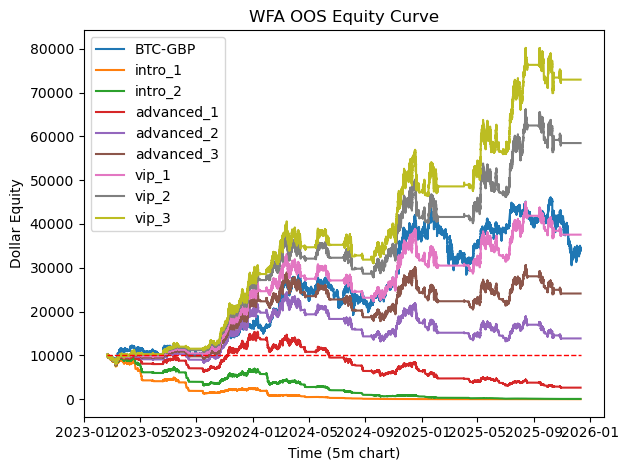

In [492]:
# OOS ground truth - the exact per-fold arrays every prediction was scored against, read straight
# from the pickle. Never rebuild them from data/: the notebook's data_universe has a different
# column order (iterdir() differs between this mac and the linux run box), a 2-row positional
# offset (cell 4 derives drop_index from one symbol, coinbase_price_return_data() uses all), and
# the folds stop 6047 bars before the dataset end - a tail-slice pairs every weight with the
# wrong asset AND the wrong bar
n_assets = wfa_w.shape[-1]
oos_asset_returns = np.array(wfa['asset_returns'], dtype = np.float64).reshape(-1, n_assets)
oos_asset_prices = np.array(wfa['asset_prices'], dtype = np.float64).reshape(-1, n_assets)
T = oos_asset_returns.shape[0]

# calendar index of every prediction (the first prediction of each fold lands on its cutoff)
if 'oos_timestamps' in wfa:
    oos_time = wfa['oos_timestamps'][0].append(wfa['oos_timestamps'][1:])
else:
    from data_loaders.coinbase_data_post_process import coinbase_price_return_data
    first_cutoff = int(60 / 5 * 24 * 50) # split_len used in run_wfa.py
    oos_time = coinbase_price_return_data(data_path)[0].index[first_cutoff: first_cutoff + T]

# guard: persisted prices must match data/ exactly under the recovered order and timestamps
raw_oos_prices = pd.concat([data_universe[s]['close'].rename(s) for s in symbols], axis = 1).loc[oos_time].to_numpy()
assert np.allclose(raw_oos_prices, oos_asset_prices), 'pickle asset order / timestamps disagree with data/'

# benchmark
initial_wealth = 1e4
oos_bench_eq = initial_wealth * np.exp(np.cumsum(oos_asset_returns[:, bench_idx]))

# equity
def backtest(asset_returns: np.ndarray,
             asset_prices: np.ndarray,
             weights: np.ndarray,
             regime_mask: np.ndarray,
             bench_idx: int,
             fee: float | None = None,
             min_turnover: float = 0.30,
             initial_wealth: float = 1.0,
             sma_window: int | None = int(60 / 5 * 100)):
    """portfolio (adjusted) equity curve from returns, with a turnover deadband on trade execution"""
    n_assets = weights.shape[-1]
    target_w = weights.reshape(-1, n_assets).copy() # continuous weight array (remove OOS boundaries)

    # OOS regime - fold crash gate, plus (optionally) bench price below its rolling SMA
    full_mask = regime_mask.reshape(-1, ).astype(bool)
    if sma_window is not None:
        bench_px = pd.Series(asset_prices[:, bench_idx])
        sma_bench = bench_px.rolling(window = sma_window).mean().to_numpy()
        full_mask = full_mask | np.nan_to_num(bench_px.to_numpy() < sma_bench, nan = False)
    target_w[full_mask] = 0.0 # dont trade cases

    T = target_w.shape[0]
    growth = np.exp(asset_returns) # exponentiate log-returns

    equity = np.empty(T)
    turnover = np.zeros(T)
    held_w_path = np.empty_like(target_w)
    held_w = np.zeros(n_assets)
    wealth = initial_wealth
    total_fees_paid = 0.0

    for t in range(T):
        to = np.abs(target_w[t] - held_w).sum() # turnover vs the actual (drifted) held position
        # deadband: skip small rebalances, but a regime-forced liquidation must always execute
        if (to >= min_turnover) or (full_mask[t] and to > 0):
            if fee is not None:
                fee_amount = wealth * to * fee
                wealth -= fee_amount
                total_fees_paid += fee_amount
            held_w = target_w[t].copy()
            turnover[t] = to

        # accounting runs every bar whether or not a trade fired - cash earns nothing, assets drift
        asset_val = held_w * growth[t]
        invested = asset_val.sum()
        cash = 1.0 - held_w.sum()
        period_growth = invested + cash
        wealth *= period_growth

        equity[t] = wealth
        held_w_path[t] = held_w
        held_w = asset_val / period_growth # carry the drifted weight into the next bar

    return {
        'inputs':
        {
            'weights': target_w
        },
        'equity': equity,
        'weights': held_w_path, # actually-held weights (post mask/drift), not the raw predictions
        'fees': total_fees_paid,
        'turnover': turnover
    }

# reconciliation: rebalance every bar, no fee, no trend overlay -> reproduces the model's own
# fee-free oos returns exp(cumsum(wfa_rt)) up to float32 rounding of the stored returns (~0.25%)
check = backtest(oos_asset_returns, oos_asset_prices, wfa_w, wfa_regime, bench_idx,
                 fee = None, min_turnover = 0.0, sma_window = None)
model_eq = np.exp(np.cumsum(wfa_rt.reshape(-1).astype(np.float64)))
print('backtest vs model equity, max |ratio - 1|:', np.abs(check['equity'] / model_eq - 1).max())

# fees
fees = {
    'no_fee': 0,
    'intro_1': 0.012,
    'intro_2': 0.0075,
    'advanced_1': 0.0040,
    'advanced_2': 0.0025,
    'advanced_3': 0.0020,
    'vip_1': 0.0016, # wfa trained on vip_1 fees be default event if post-hoc OOS fees differ
    'vip_2': 0.0012,  
    'vip_3': 0.0010, 
}
# minimum turnover
min_to = 0.4
# sma days 
sma_window = int(60 / 5 * 24 * 40)
# equity dicts
wfa_eq = {}
for tier, fee in fees.items():
    wfa_eq[tier] = backtest(asset_returns = oos_asset_returns,
                            asset_prices = oos_asset_prices,
                            weights = wfa_w,
                            regime_mask = wfa_regime,
                            bench_idx = bench_idx,
                            fee = fee,
                            initial_wealth = initial_wealth, 
                            min_turnover = min_to,
                            sma_window = sma_window)

# plot equity
plt.plot(oos_time, oos_bench_eq, linestyle = '-')
for tier in list(wfa_eq.keys())[1:]:
    plt.plot(oos_time, wfa_eq[tier]['equity'])
plt.hlines(initial_wealth, oos_time[0], oos_time[-1], color = 'red', linestyle = '--', linewidth = 1)
plt.title('WFA OOS Equity Curve')
plt.xlabel('Time (5m chart)')
plt.ylabel('Dollar Equity')
plt.legend([bench] + list(fees.keys())[1:])
plt.tight_layout()
plt.show();

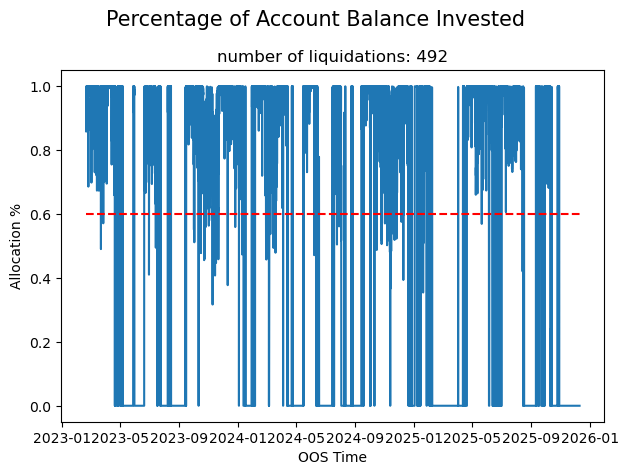

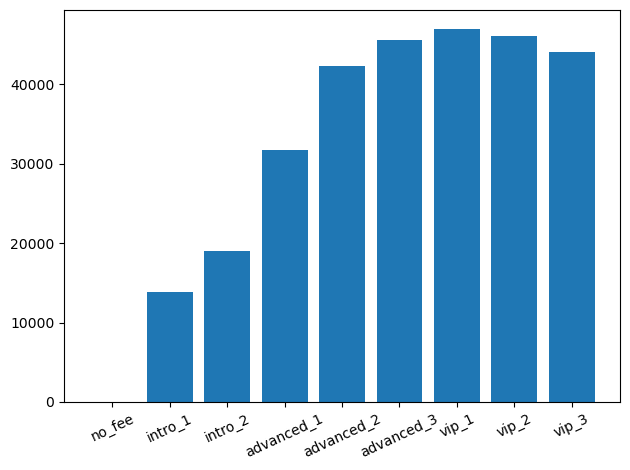

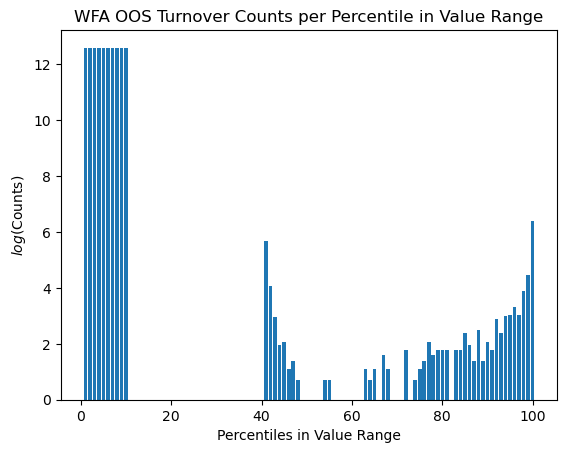

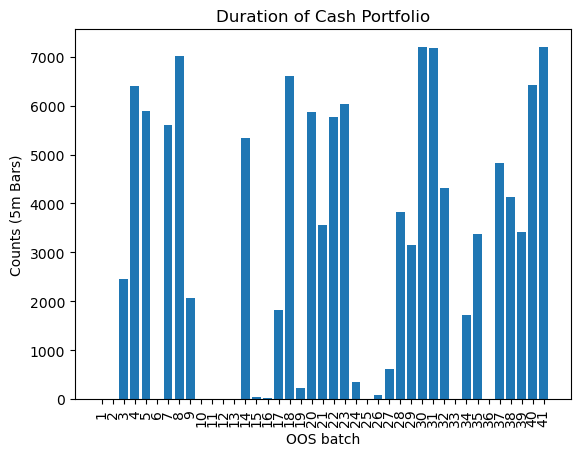

In [493]:
# allocation over time 
oos_w = wfa_eq['no_fee']['inputs']['weights']
full_oos_w = oos_w.sum(axis = 1)
zero_allocation = np.where(full_oos_w == 0, True, False)
shift_zero_allocation = np.concat(([False], zero_allocation[: -1]))
investment_bounadries = zero_allocation & ~shift_zero_allocation
n_liquidations = len(investment_bounadries[investment_bounadries == 1])
plt.plot(oos_time, full_oos_w)
plt.suptitle('Percentage of Account Balance Invested', fontsize = 15)
plt.title(f'number of liquidations: {n_liquidations}')
plt.xlabel('OOS Time')
plt.ylabel('Allocation %')
plt.hlines(1 - min_to, oos_time[0], oos_time[-1], linestyle = '--', color = 'red')
plt.tight_layout()
plt.show(); 

# fees paid per tier
fees_dict = {tier: fee['fees'].item() for tier, fee in wfa_eq.items()}
plt.bar(fees_dict.keys(), fees_dict.values())
plt.xticks(rotation  = 25)
plt.tight_layout()
plt.show();

# turnover percentile counts plot
# calculate turnover
turnover = wfa_eq['advanced_1']['turnover']
turnover_decile_counts = {}

percentiles = []
max_turnover = turnover.max()
for q in range(1, 101, 1):
    p_high = max_turnover * q / 100
    decile_low_counts = 0
    if q > 10:
        p_low = percentiles[-1]
        decile_low_counts = len(turnover[turnover <= p_low])
    decile_counts = len(turnover[turnover <= p_high]) - decile_low_counts

    percentiles.append(p_high.item())

    turnover_decile_counts[q] = np.log(decile_counts) if (decile_counts > 0) else 0
    
plt.bar(turnover_decile_counts.keys(), turnover_decile_counts.values())
plt.title('WFA OOS Turnover Counts per Percentile in Value Range')
plt.xlabel('Percentiles in Value Range')
plt.ylabel(r'$log$(Counts)')
plt.show()

# cash portfolio duration in each OOS batch
num_full_turnovers_per_batch = {}
for batch, w_batch in enumerate(oos_w.reshape(wfa_w.shape)): 
    row_sums = w_batch.sum(axis = 1)
    num_full_turnovers_per_batch[batch + 1] = row_sums[row_sums == 0].shape[0]

plt.bar(num_full_turnovers_per_batch.keys(), num_full_turnovers_per_batch.values())
plt.title('Duration of Cash Portfolio')
plt.xlabel('OOS batch')
plt.xticks(list(range(1, wfa_w.shape[0] + 1)), rotation = 90)
plt.ylabel('Counts (5m Bars)')
plt.show();